### **1. Setup & Imports**

This section handles the initial setup of the environment. It installs necessary Python packages, imports all required libraries from these packages

In [28]:
%%capture
!pip install -U peft torchao optuna

In [29]:
import random
import time
import re
from typing import Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, TaskType, get_peft_model

import optuna

from warnings import filterwarnings
filterwarnings('ignore')

In [30]:
# ============================================================
# Check if current device is GPU
# ============================================================
if torch.cuda.is_available():
    print("Running on GPU!")
    DEVICE = torch.device("cuda")
else:
    print("Running on CPU!")
    DEVICE = torch.device("cpu")

# Set a global seed for reproducibility
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_global_seed(SEED)
print(f"Global random seed set to {SEED}")

Running on GPU!
Global random seed set to 42


### **2. Dataset Loading & EDA**
The dataset combines formal financial news sentences with short, informal stock market tweets, all labelled positive, negative, or neutral. [`Kaggle Dataset Link`](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis)

In [31]:
# Load data into dataframe
DATA_URL = (
    "https://raw.githubusercontent.com/faadeola/LLM-financial-sentiment-analysis/"
    "refs/heads/main/Financial%20Sentiment%20Analysis%20Data.csv"
)

df = pd.read_csv(DATA_URL)
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns \n')
df.head()

The dataset contains 5842 rows and 2 columns 



,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [32]:
# Display counts of labels
df["Sentiment"].value_counts()

,count
Sentiment,
neutral,3130
positive,1852
negative,860


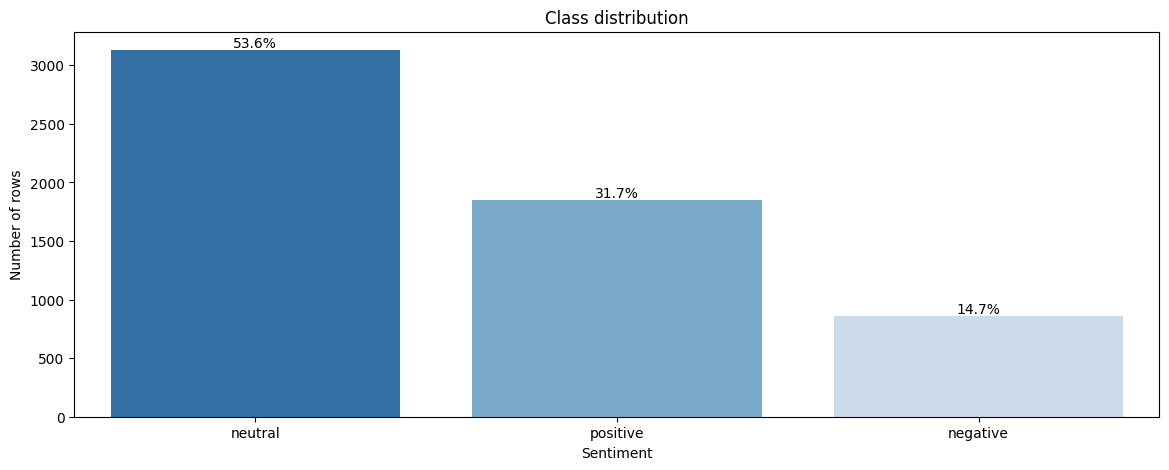

In [33]:
class_counts = df["Sentiment"].value_counts()
class_props = df["Sentiment"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='Blues_r')
ax.set_title("Class distribution")
ax.set_ylabel("Number of rows")
for i, (count, prop) in enumerate(zip(class_counts.values, class_props.values)):
    ax.text(i, count + 20, f"{prop:.1%}", ha="center")
plt.show()

In [34]:
print("Missing values:")
print(df.isnull().sum())

print("\nExact duplicate rows (same sentence and same label):", df.duplicated().sum())
print("Duplicate sentences (any label):", df["Sentence"].duplicated().sum())

repeated = df[df["Sentence"].duplicated(keep=False)]
label_conflicts = repeated.groupby("Sentence")["Sentiment"].nunique()
label_conflicts = label_conflicts[label_conflicts > 1]
print("Sentences that appear more than once with different labels:", len(label_conflicts))

Missing values:
Sentence     0
Sentiment    0
dtype: int64

Exact duplicate rows (same sentence and same label): 6
Duplicate sentences (any label): 520
Sentences that appear more than once with different labels: 514


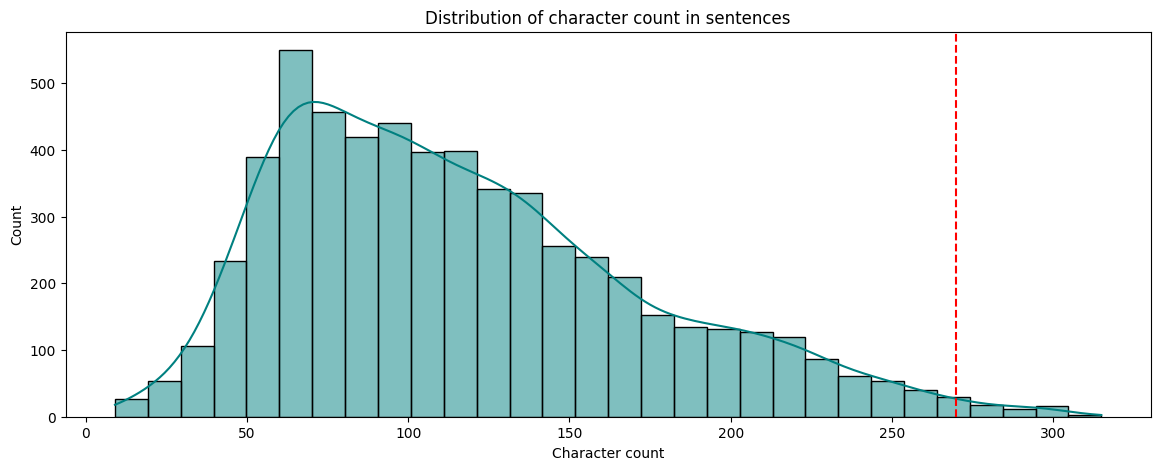

,char_length
count,5842.000000
mean,117.022253
std,56.420425
min,9.000000
25%,72.000000
50%,107.000000
75%,150.000000
max,315.000000


In [66]:
df["char_length"] = df["Sentence"].str.len()

fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(df["char_length"], ax=ax, kde=True, color='teal', bins=30)
plt.axvline(x=df["char_length"].quantile(0.99), color="red", linestyle="--", label='99th Percentile')
ax.set_title("Distribution of character count in sentences")
ax.set_xlabel("Character count")
plt.show()

df["char_length"].describe()

In [36]:
# Flag sentence that contains tweet style format (hashtags)
tweet_pattern = r"\$[A-Za-z]+|https?://|#\w+"
df["looks_like_tweet"] = df["Sentence"].str.contains(tweet_pattern, regex=True)
df["looks_like_tweet"].value_counts()

,count
looks_like_tweet,
False,5167
True,675


### **3. Cleaning and Preprocessing**

In [37]:
# function to clean text in one go
def clean_text(text):
    """Basic text cleaning function for Transformer models."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()   # Remove redundant whitespace
    return text

In [38]:
# Clean the text and drop exact duplicates
df_clean = df.copy()
df_clean["Sentence"] = df_clean["Sentence"].apply(clean_text)

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Sentence", "Sentiment"]).reset_index(drop=True)
print(f"Rows before: {rows_before}, rows after cleaning and dropping exact duplicates: {len(df_clean)}")

df_clean = df_clean[["Sentence", "Sentiment"]].copy()

Rows before: 5842, rows after cleaning and dropping exact duplicates: 5831


In [39]:
# label encoding for the sentiment labels
label_encoder = LabelEncoder()
df_clean["label"] = label_encoder.fit_transform(df_clean["Sentiment"])

# Create a mapping of original labels to encoded labels
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_map)

# Get the list of class names
class_names = label_encoder.classes_.tolist()

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [40]:
# dataset splitting for llm trainings
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    df_clean["Sentence"].tolist(),
    df_clean["label"].tolist(),
    test_size=0.15,
    random_state=SEED,
    stratify=df_clean["label"],
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts,
    train_val_labels,
    test_size=0.15,
    random_state=SEED,
    stratify=train_val_labels,
)

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 4212, Val: 744, Test: 875


In [41]:
"""
  The baseline doesn't need held out validation set for early stopping,
  so it trains on train+val while FinBERT trains on train only and monitors on val. So, both are evaluated on the same test set.
"""
baseline_train_texts = train_texts + val_texts
baseline_train_labels = train_labels + val_labels

### **4. Reusable Functions**

In [42]:
def get_metrics(y_true, y_pred, average="macro"):
    """
        This function computes accuracy, precision, recall, and F1 score for the model's predictions.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=average, zero_division=0
    )
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """
        Plot a confusion matrix and return the confusion matrix object
    """

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.show()
    return cm


def show_results(model_name, texts, y_true, y_pred, label_encoder, class_names, n_rows=10):
    """
        This function is used to display the results of a model's predictions.
        It prints the classification report, which includes metrics such as precision, recall, and F1-score for each class.
        It also creates a DataFrame that shows the original text, the actual label, and the predicted label.
    """

    print(f"--- {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    preds_df = pd.DataFrame({
        "text": texts,
        "actual": label_encoder.inverse_transform(y_true),
        "predicted": label_encoder.inverse_transform(y_pred),
    })
    display(preds_df.head(n_rows))

    return preds_df


def plot_loss_curve(history, title):
    """
        This function is used to plot the loss curve for the model during training.
        It takes in the training history and a title for the plot, and it generates a line plot showing the training and validation loss over epochs.
        This helps visualize how well the model is learning and whether it is overfitting or underfitting.
    """

    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epochs_range, history["train_loss"], marker="o", label="Train loss")
    ax.plot(epochs_range, history["val_loss"], marker="o", label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.legend()
    plt.show()

# To store all results
results = {}

### **5. Baseline Model: TF-IDF + Logistic Regression**
This section is divided into the baseline model with default parameters and then optimized parameters

#### **5.1 Baseline Model (Default)**

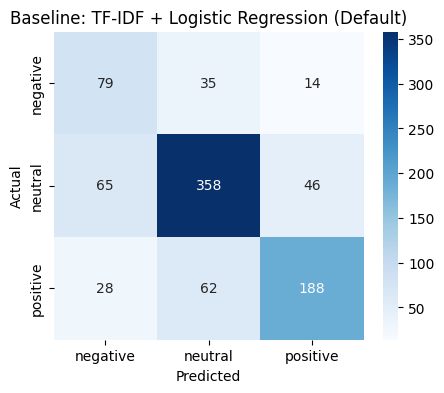

--- Baseline (default) ---
              precision    recall  f1-score   support

    negative       0.46      0.62      0.53       128
     neutral       0.79      0.76      0.77       469
    positive       0.76      0.68      0.71       278

    accuracy                           0.71       875
   macro avg       0.67      0.69      0.67       875
weighted avg       0.73      0.71      0.72       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,neutral
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,negative
3,$AAPL Clearing this descending trend line / bu...,positive,positive
4,`` Leipurin is a growing and rapidly internati...,positive,neutral
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,neutral
9,Panostaja did not disclose the purchase price .,neutral,neutral


In [43]:
# Set Tf-IDF vectorizer with unigrams and bigrams, and limit to 10,000 features
# Tf-IDF helps to convert text data into numerical features by calculating the importance of each word in a document relative to the entire collection.
# By using unigrams and bigrams, model is able to capture both individual words and pairs of consecutive words, which can provide more context for sentiment analysis.
# Fit the vectorizer on the training data and transform both training and test data

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(baseline_train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

# Train a baseline Logistic Regression model on the TF-IDF features with class weights to handle class imbalance.
baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train_tfidf, baseline_train_labels)

# Make predictions on the test set
baseline_preds = baseline_model.predict(X_test_tfidf)

# Plot confusion matrix for baseline model
plot_confusion_matrix(test_labels, baseline_preds, class_names, "Baseline: TF-IDF + Logistic Regression (Default)")

# Show results for baseline
baseline_preds_df = show_results(
    "Baseline (default)", test_texts, test_labels, baseline_preds,
    label_encoder, class_names,
)

In [44]:
# Store and show default baseline results
results["baseline"] = get_metrics(test_labels, baseline_preds)
results["baseline"]

{'accuracy': 0.7142857142857143,
 'precision': 0.6680600095078715,
 'recall': 0.6855909062728495,
 'f1': 0.6721291129656147}

#### **5.2 Baseline Model (Optimized)**
`RandomizedSearchCV` samples a fixed number of parameter combinations (`n_iter`) instead of
trying every combination, which keeps the search fast. The vectorizer and classifier are
wrapped in a `Pipeline` so TF-IDF is refit on each cross-validation fold, avoiding leakage.

In [45]:
# Set up a pipeline for the baseline model
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

# Define hyperparameter search space for RandomizedSearchCV
param_distributions = {
    "tfidf__max_features": [5000, 10000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 1, 10],
}

# Set up RandomizedSearchCV for hyperparameter tuning
baseline_search = RandomizedSearchCV(
    baseline_pipeline,
    param_distributions,
    n_iter=6,
    scoring="f1_macro",
    cv=3,
    random_state=SEED,
    n_jobs=-1,
)

# Fit the RandomizedSearchCV on the training data
baseline_search.fit(baseline_train_texts, baseline_train_labels)

# print the best parameters found by RandomizedSearchCV
print("Best baseline params:", baseline_search.best_params_)

# Get the best estimator and make predictions on the test set
optimized_baseline_model = baseline_search.best_estimator_
optimized_baseline_preds = optimized_baseline_model.predict(test_texts)

Best baseline params: {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 5000, 'clf__C': 1}


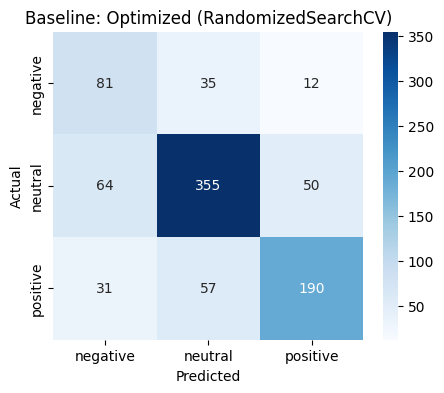

--- Baseline (optimized) ---
              precision    recall  f1-score   support

    negative       0.46      0.63      0.53       128
     neutral       0.79      0.76      0.78       469
    positive       0.75      0.68      0.72       278

    accuracy                           0.72       875
   macro avg       0.67      0.69      0.67       875
weighted avg       0.73      0.72      0.72       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,neutral
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,negative
3,$AAPL Clearing this descending trend line / bu...,positive,positive
4,`` Leipurin is a growing and rapidly internati...,positive,neutral
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,neutral
9,Panostaja did not disclose the purchase price .,neutral,neutral


In [46]:
# Show confusion matrix for optimized baseline
plot_confusion_matrix(test_labels, optimized_baseline_preds, class_names, "Baseline: Optimized (RandomizedSearchCV)")

# Show results for optimized baseline
baseline_opt_preds_df = show_results(
    "Baseline (optimized)", test_texts, test_labels, optimized_baseline_preds,
    label_encoder, class_names,
)

In [47]:
# Store metrics for optimized baseline
results["baseline_optimized"] = get_metrics(test_labels, optimized_baseline_preds)
results["baseline_optimized"]

{'accuracy': 0.7154285714285714,
 'precision': 0.6694596572952278,
 'recall': 0.6910651249789082,
 'f1': 0.6749950130744179}

### **6. Fine-tuned Finbert Model**

#### **6.1 Tokenization and Dataset Preparation**

In [48]:
""" Initialize the FinBERT model and tokenizer """
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Define maximum sequence length for tokenization
MAX_LENGTH = 64

In [49]:
# Custom dataset class for BETR style sentiment analysis
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            texts, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

# Create datasets for training, validation, and testing
train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, MAX_LENGTH)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, MAX_LENGTH)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 4212
Val dataset size: 744
Test dataset size: 875


In [50]:
# Compute class weights for imbalanced dataset
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(DEVICE)

for name, weight in zip(class_names, class_weights_array):
    print(f"{name}: weight {weight:.3f}")

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

negative: weight 2.265
neutral: weight 0.622
positive: weight 1.051


#### **6.2 Model Building and Training**
This section is used for the `fine-tuned finbert model` using `torch` and training loop composed of appropriate optimizer and loss function. Also, the fine-tuned model was trained using default parameter and also optimized parameter using `Optuna` for hyperparameter search and `LoRa` for optimization.

In [51]:
# ============================================================
# Model building and training functions
# ============================================================

# Build the model
def build_model(use_lora=False, lora_config=None):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(class_names)
    )

    if use_lora:
        if lora_config is None:
            # Default LoRA config if not provided
            lora_config = LoraConfig(
                r=8,
                lora_alpha=16,
                target_modules=["query", "value"],
                lora_dropout=0.1,
                bias="none",
                task_type=TaskType.SEQ_CLS,
            )
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()

    return model.to(DEVICE)

# Run training epoch
def run_training_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(labels)

    return running_loss / len(dataloader.dataset)

# Run evaluation
def run_evaluation(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            running_loss += loss.item() * len(labels)

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader.dataset)
    return avg_loss, all_preds, all_labels


# Train the model
def train_model(model, train_loader, val_loader, optimizer, loss_fn, device, epochs):
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        start = time.time()
        train_loss = run_training_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, _, _ = run_evaluation(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        elapsed = time.time() - start
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
            f"{elapsed:.1f}s"
        )

    return model, history

##### **6.2.1 FinbertfFine-tuned model (Default Hyperparameters)**

In [52]:
# Default hyperparameters for training
DEFAULT_LEARNING_RATE = 2e-5
DEFAULT_BATCH_SIZE = 16
DEFAULT_EPOCHS = 3

# Create default data loaders
default_train_loader = DataLoader(train_dataset, batch_size=DEFAULT_BATCH_SIZE, shuffle=True)
default_val_loader = DataLoader(val_dataset, batch_size=DEFAULT_BATCH_SIZE)
default_test_loader = DataLoader(test_dataset, batch_size=DEFAULT_BATCH_SIZE)

# Build the default model
default_model = build_model(use_lora=True)
default_optimizer = AdamW(default_model.parameters(), lr=DEFAULT_LEARNING_RATE)

# Train the default model
default_model, default_history = train_model(
    default_model, default_train_loader, default_val_loader,
    default_optimizer, loss_fn, DEVICE, DEFAULT_EPOCHS,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707
Epoch 1/3 | train loss: 1.8059 | val loss: 1.0002 | 41.3s
Epoch 2/3 | train loss: 0.7769 | val loss: 0.6011 | 34.9s
Epoch 3/3 | train loss: 0.5696 | val loss: 0.5040 | 35.4s


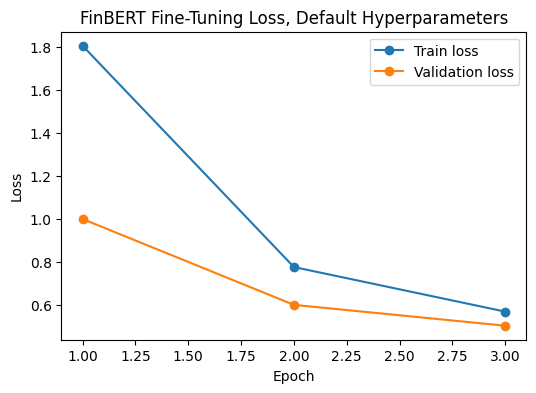

In [53]:
# Plot the training loss curve
plot_loss_curve(default_history, "FinBERT Fine-Tuning Loss, Default Hyperparameters")

# Evaluate the default model
_, default_test_preds, default_test_labels = run_evaluation(
    default_model, default_test_loader, loss_fn, DEVICE
)

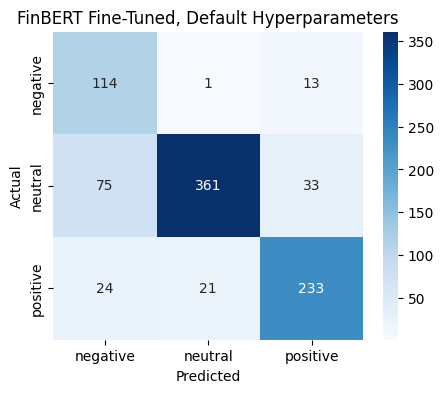

--- FinBERT (default) ---
              precision    recall  f1-score   support

    negative       0.54      0.89      0.67       128
     neutral       0.94      0.77      0.85       469
    positive       0.84      0.84      0.84       278

    accuracy                           0.81       875
   macro avg       0.77      0.83      0.78       875
weighted avg       0.85      0.81      0.82       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,negative
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,positive
3,$AAPL Clearing this descending trend line / bu...,positive,positive
4,`` Leipurin is a growing and rapidly internati...,positive,positive
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,positive
9,Panostaja did not disclose the purchase price .,neutral,neutral


{'accuracy': 0.8091428571428572,
 'precision': 0.7709651541235334,
 'recall': 0.8328257703006039,
 'f1': 0.7842214389462784}

In [54]:
# Plot confusion matrix for the default model
plot_confusion_matrix(
    default_test_labels, default_test_preds, class_names,
    "FinBERT Fine-Tuned, Default Hyperparameters",
)

# Show results for the default model
finbert_default_preds_df = show_results(
    "FinBERT (default)", test_texts, default_test_labels, default_test_preds,
    label_encoder, class_names,
)

# Store metrics for the default model
results["finetuned_default"] = get_metrics(default_test_labels, default_test_preds)
results["finetuned_default"]

##### **6.2.2 Finbert fine-tuned model (Optimized using Optuna)**

In [55]:
# ============================================================
# Hyperparameter search using Optuna
# ============================================================

# Define the number of epochs for hyperparameter search
SEARCH_EPOCHS = 4

# Define the hyperparameter search space for Optuna
def hp_space(trial: optuna.Trial) -> Dict[str, Any]:
    r = trial.suggest_categorical("r", [4, 8, 16, 32])
    return {
        "r": r,
        "lora_alpha": 2 * r,
        "lora_dropout": trial.suggest_float("lora_dropout", 0.0, 0.3),
        "learning_rate": trial.suggest_float("learning_rate", 5e-5, 5e-4, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32]),
    }

In [56]:
# Define the objective function for Optuna
def objective(trial):
    params = hp_space(trial)

    lora_config = LoraConfig(
        r=params["r"],
        lora_alpha=params["lora_alpha"],
        target_modules=["query", "value"],
        lora_dropout=params["lora_dropout"],
        bias="none",
        task_type=TaskType.SEQ_CLS,
    )

    # Create data loaders for the trial
    trial_train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    trial_val_loader = DataLoader(val_dataset, batch_size=params["batch_size"])

    # Build the model with LoRA and the specified hyperparameters
    model = build_model(use_lora=True, lora_config=lora_config)
    optimizer = AdamW(model.parameters(), lr=params["learning_rate"])

    # Train the model for the specified number of epochs
    model, _ = train_model(
        model, trial_train_loader, trial_val_loader,
        optimizer, loss_fn, DEVICE, SEARCH_EPOCHS,
    )

    # Evaluate the model on the validation set and return the F1 score
    _, val_preds, val_true = run_evaluation(model, trial_val_loader, loss_fn, DEVICE)
    val_f1 = get_metrics(val_true, val_preds)["f1"]

    # Clean up to free GPU memory
    del model, optimizer
    torch.cuda.empty_cache()

    return val_f1

In [57]:
# Run the hyperparameter search using Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Print the best hyperparameters and the corresponding validation F1 score
print("Best params:", study.best_params)
print("Best val F1:", study.best_value)

[I 2026-07-30 22:18:53,599] A new study created in memory with name: no-name-2daa605c-5bb0-4d82-8d15-4e4c19bc20f4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 149,763 || all params: 109,634,310 || trainable%: 0.1366
Epoch 1/4 | train loss: 0.8142 | val loss: 0.4762 | 35.8s
Epoch 2/4 | train loss: 0.4482 | val loss: 0.4366 | 35.1s
Epoch 3/4 | train loss: 0.4120 | val loss: 0.4190 | 35.3s
Epoch 4/4 | train loss: 0.3863 | val loss: 0.4253 | 35.4s


[I 2026-07-30 22:21:19,313] Trial 0 finished with value: 0.7859205038183061 and parameters: {'r': 4, 'lora_dropout': 0.1174288174045757, 'learning_rate': 0.00022126842323121052, 'batch_size': 32}. Best is trial 0 with value: 0.7859205038183061.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

[I 2026-07-30 23:05:26,103] Trial 18 finished with value: 0.7849062028144006 and parameters: {'r': 8, 'lora_dropout': 0.05798024155356457, 'learning_rate': 0.00021489862642823946, 'batch_size': 16}. Best is trial 8 with value: 0.8031655535698671.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 592,131 || all params: 110,076,678 || trainable%: 0.5379
Epoch 1/4 | train loss: 0.6564 | val loss: 0.4406 | 35.6s
Epoch 2/4 | train loss: 0.4212 | val loss: 0.4092 | 35.7s
Epoch 3/4 | train loss: 0.3726 | val loss: 0.4005 | 35.8s
Epoch 4/4 | train loss: 0.3257 | val loss: 0.4119 | 35.8s


[I 2026-07-30 23:07:53,157] Trial 19 finished with value: 0.78640654571871 and parameters: {'r': 16, 'lora_dropout': 0.17509861820582276, 'learning_rate': 0.0001838426242866937, 'batch_size': 16}. Best is trial 8 with value: 0.8031655535698671.


Best params: {'r': 8, 'lora_dropout': 0.24601527382362004, 'learning_rate': 0.00022036334704639274, 'batch_size': 16}
Best val F1: 0.8031655535698671


In [58]:
# Extract the best hyperparameters and compute derived lora_alpha
best_params = study.best_params
best_lora_alpha = 2 * best_params["r"]

# Print the best hyperparameters and derived lora_alpha
print(f"Best hyperparameters: {best_params}")
print(f"Derived lora_alpha: {best_lora_alpha}")

Best hyperparameters: {'r': 8, 'lora_dropout': 0.24601527382362004, 'learning_rate': 0.00022036334704639274, 'batch_size': 16}
Derived lora_alpha: 16


**-- Model Training with best optimized parameters**

In [59]:
# Define the number of epochs for the final training with tuned hyperparameters
TUNED_EPOCHS = 4

# Build the best LoRA configuration based on the best hyperparameters
best_lora_config = LoraConfig(
    r=best_params["r"],
    lora_alpha=best_lora_alpha,
    target_modules=["query", "value"],
    lora_dropout=best_params["lora_dropout"],
    bias="none",
    task_type=TaskType.SEQ_CLS,
)

# Create data loaders for the final training with tuned hyperparameters
tuned_train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
tuned_val_loader = DataLoader(val_dataset, batch_size=best_params["batch_size"])
tuned_test_loader = DataLoader(test_dataset, batch_size=best_params["batch_size"])

# Build the model with the best hyperparameters and train it
tuned_model = build_model(use_lora=True, lora_config=best_lora_config)
tuned_optimizer = AdamW(tuned_model.parameters(), lr=best_params["learning_rate"])

# Train the model with the tuned hyperparameters
tuned_model, tuned_history = train_model(
    tuned_model, tuned_train_loader, tuned_val_loader,
    tuned_optimizer, loss_fn, DEVICE, TUNED_EPOCHS,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

trainable params: 297,219 || all params: 109,781,766 || trainable%: 0.2707
Epoch 1/4 | train loss: 0.6560 | val loss: 0.4480 | 35.5s
Epoch 2/4 | train loss: 0.4293 | val loss: 0.4293 | 35.3s
Epoch 3/4 | train loss: 0.3903 | val loss: 0.4193 | 35.6s
Epoch 4/4 | train loss: 0.3473 | val loss: 0.4014 | 35.7s


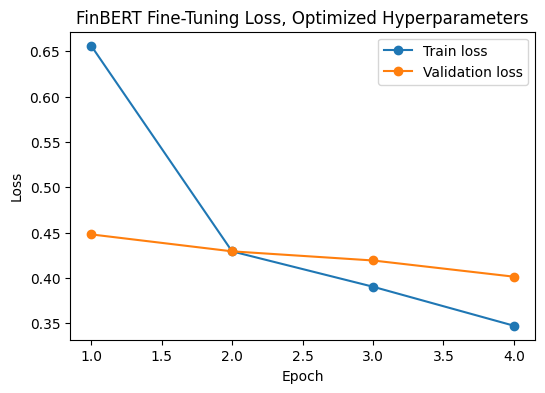

In [60]:
# Plot the training loss curve for the tuned model
plot_loss_curve(tuned_history, "FinBERT Fine-Tuning Loss, Optimized Hyperparameters")

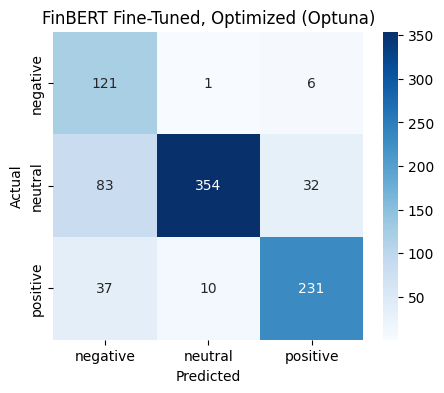

--- FinBERT (tuned) ---
              precision    recall  f1-score   support

    negative       0.50      0.95      0.66       128
     neutral       0.97      0.75      0.85       469
    positive       0.86      0.83      0.84       278

    accuracy                           0.81       875
   macro avg       0.78      0.84      0.78       875
weighted avg       0.87      0.81      0.82       875



,text,actual,predicted
0,Finnish Kemira 's net sales EUR decreased to E...,negative,negative
1,"Therefore , the company 's 2005 result will re...",negative,negative
2,@CH_Roark: $UNXL I like this Ascending Triangl...,positive,positive
3,$AAPL Clearing this descending trend line / bu...,positive,negative
4,`` Leipurin is a growing and rapidly internati...,positive,positive
5,"ADP News - Nov 18 , 2008 - Finnish AC drives m...",positive,positive
6,Aldata said that there are still a number of o...,neutral,neutral
7,Finnish software developer Done Solutions Oyj ...,positive,positive
8,"F-Secure , a developer of security solutions a...",neutral,neutral
9,Panostaja did not disclose the purchase price .,neutral,neutral


{'accuracy': 0.8068571428571428,
 'precision': 0.7768912539916215,
 'recall': 0.843681731054389,
 'f1': 0.7831181228528273}

In [61]:
# Evaluate the tuned model on the test set
_, tuned_test_preds, tuned_test_labels = run_evaluation(
    tuned_model, tuned_test_loader, loss_fn, DEVICE
)

# Plot confusion matrix for the tuned model
plot_confusion_matrix(
    tuned_test_labels, tuned_test_preds, class_names,
    "FinBERT Fine-Tuned, Optimized (Optuna)",
)

# Show results for the tuned model
finbert_tuned_preds_df = show_results(
    "FinBERT (tuned)", test_texts, tuned_test_labels, tuned_test_preds,
    label_encoder, class_names,
)

# Store metrics for the tuned model
results["finetuned_tuned"] = get_metrics(tuned_test_labels, tuned_test_preds)
results["finetuned_tuned"]

### **7 Model Comparison**

In [62]:
# Create a comparison DataFrame for all models
comparison_df = pd.DataFrame(results).T
comparison_df.index = [
    "Baseline (default)", "Baseline (optimized)",
    "FinBERT (default)", "FinBERT (tuned)",
]

# Display the comparison DataFrame
comparison_df

,accuracy,precision,recall,f1
Baseline (default),0.714286,0.668060,0.685591,0.672129
Baseline (optimized),0.715429,0.669460,0.691065,0.674995
FinBERT (default),0.809143,0.770965,0.832826,0.784221
FinBERT (tuned),0.806857,0.776891,0.843682,0.783118


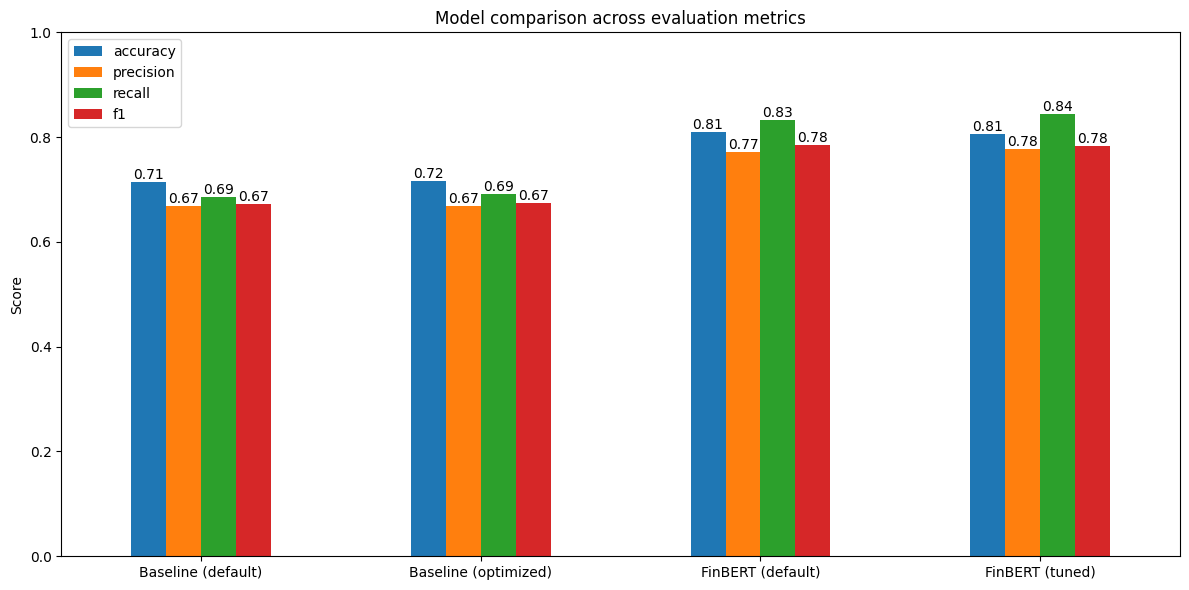

In [63]:
""" Plot comparison of models across evaluation metrics """
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]

fig, ax = plt.subplots(figsize=(12, 6))
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("Model comparison across evaluation metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="best")
plt.xticks(rotation=0)

# Displays values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

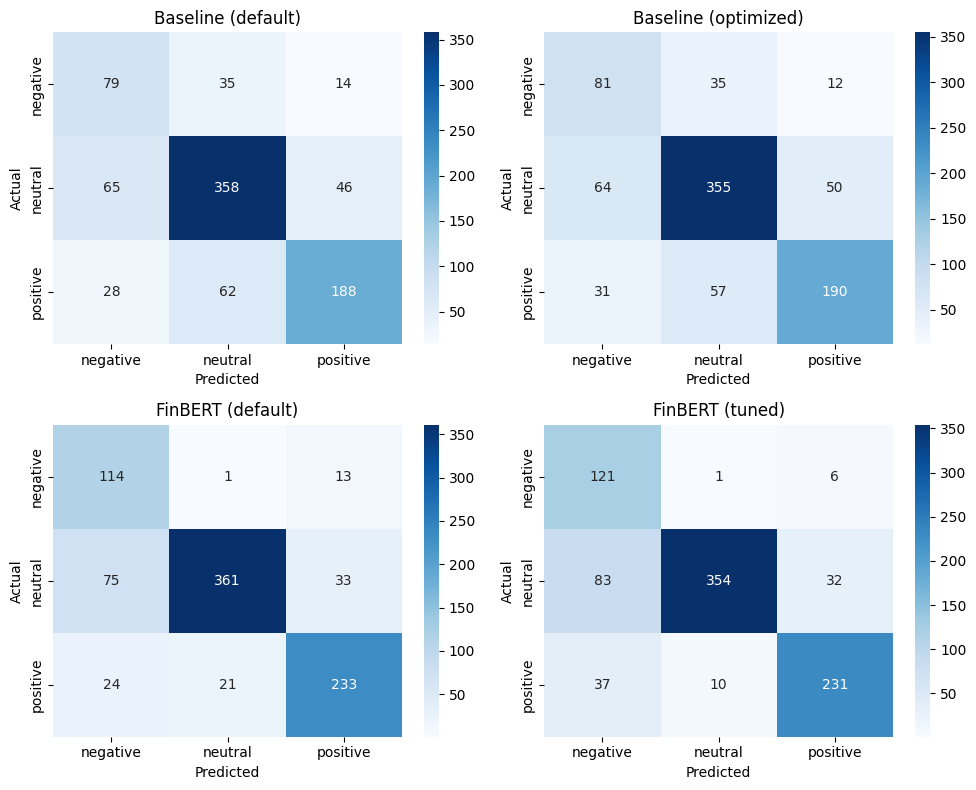

In [64]:
""" Plot confusion matrices for all models in a 2x2 grid """
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

model_predictions = {
    "Baseline (default)": (test_labels, baseline_preds),
    "Baseline (optimized)": (test_labels, optimized_baseline_preds),
    "FinBERT (default)": (default_test_labels, default_test_preds),
    "FinBERT (tuned)": (tuned_test_labels, tuned_test_preds),
}

for ax, (name, (y_true, y_pred)) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### **8 Model Predictions**

In [65]:
# Create a comparison DataFrame for all model predictions
comparison_preds_df = pd.DataFrame({
    "text": test_texts,
    "actual": label_encoder.inverse_transform(test_labels),
    "baseline_default": label_encoder.inverse_transform(baseline_preds),
    "baseline_optimized": label_encoder.inverse_transform(optimized_baseline_preds),
    "finbert_default": label_encoder.inverse_transform(default_test_preds),
    "finbert_tuned": label_encoder.inverse_transform(tuned_test_preds),
})

# Display 10 random rows of the comparison predictions DataFrame
comparison_preds_df.sample(10)

,text,actual,baseline_default,baseline_optimized,finbert_default,finbert_tuned
797,Latin America currently accounts for approxima...,neutral,neutral,neutral,neutral,neutral
319,Konecranes Oyj KCR1V FH fell 5.5 percent to 20...,negative,negative,negative,negative,negative
382,"Copper , lead and nickel also dropped ... HBOS...",neutral,positive,positive,negative,negative
790,This transaction will also rationalize our pul...,positive,neutral,neutral,positive,positive
422,Poyry is a global consulting and engineering f...,neutral,neutral,neutral,neutral,neutral
327,Primark racks up a happy Christmas after stron...,positive,positive,positive,positive,positive
806,"However , the offering will probably not be ma...",neutral,neutral,neutral,neutral,neutral
136,Price talk is in the Euribor plus 2 bps area a...,neutral,neutral,neutral,neutral,positive
685,"In the end of 2006 , the number of outlets wil...",positive,neutral,neutral,positive,positive
779,Sanoma News ' advertising sales decreased by 2...,neutral,negative,negative,negative,negative
